In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [82]:
dfT254 = pd.read_csv('../Results/post_matching_T2_54WR.csv')
dfT256 = pd.read_csv('../Results/post_matching_T2_56WR.csv')
dfT258 = pd.read_csv('../Results/post_matching_T2_58WR.csv')
dfT260 = pd.read_csv('../Results/post_matching_T2_60WR.csv')
dfT262 = pd.read_csv('../Results/post_matching_T2_62WR.csv')

dfT254PRE = pd.read_csv('../Results/pre_matching_df_T2_54WR.csv')
dfT256PRE = pd.read_csv('../Results/pre_matching_df_T2_56WR.csv')
dfT258PRE = pd.read_csv('../Results/pre_matching_df_T2_58WR.csv')
dfT260PRE = pd.read_csv('../Results/pre_matching_df_T2_60WR.csv')
dfT262PRE = pd.read_csv('../Results/pre_matching_df_T2_62WR.csv')

In [74]:
dfT262PRE.head()

,Unnamed: 0,draft_id,treatment,control,pack_number,pick_number,color_identity,W_mean,U_mean,B_mean,R_mean,G_mean,event_match_wins,event_match_losses,W_id,U_id,B_id,R_id,G_id
0,7,ca9c82901d6844109a9fae4726b5d99f,False,True,0,7,"['W', 'G']",NaN,5.939530,8.299559,7.166909,7.402079,1,3,1,0,0,0,1
1,20,ca9c82901d6844109a9fae4726b5d99f,False,True,1,6,"['G', 'W']",NaN,6.036871,6.097201,6.565309,NaN,1,3,1,0,0,0,1
2,22,ca9c82901d6844109a9fae4726b5d99f,False,True,1,8,"['W', 'G']",6.819423,7.094136,3.604353,7.276649,NaN,1,3,1,0,0,0,1
3,23,ca9c82901d6844109a9fae4726b5d99f,False,True,1,9,"['W', 'G']",5.617755,4.538467,NaN,6.716163,NaN,1,3,1,0,0,0,1
4,34,ca9c82901d6844109a9fae4726b5d99f,False,True,2,6,"['G', 'W']",NaN,6.298852,6.472305,7.450303,7.432742,1,3,1,0,0,0,1


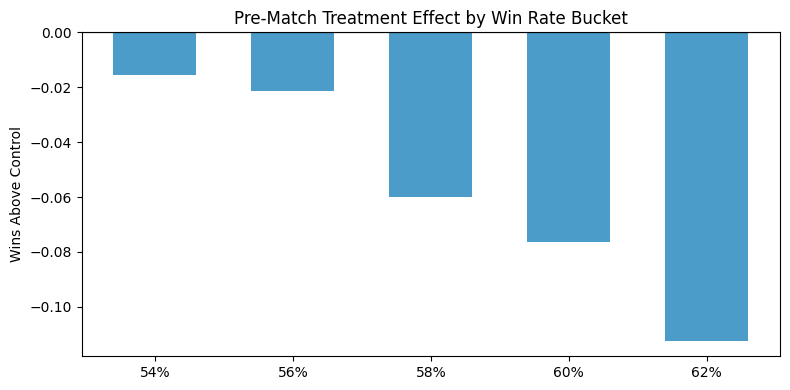

In [95]:
pre_match_dfs = [dfT254PRE, dfT256PRE, dfT258PRE, dfT260PRE, dfT262PRE]
labels = ['54%', '56%', '58%', '60%', '62%']
results = []

for item in pre_match_dfs:
    no_match_results_df = item
    no_match_treat_wins = no_match_results_df[no_match_results_df['treatment']]['event_match_wins'].mean()
    no_match_control_wins = no_match_results_df[~no_match_results_df['treatment']]['event_match_wins'].mean()
    wins_above_control = no_match_treat_wins - no_match_control_wins
    results.append(wins_above_control)

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x=range(len(results)), height=results,
       color=np.where(np.array(results) >= 0, '#d55e00', '#0072b2'),
       alpha=0.7, width=0.6)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xticks(range(len(results)))
ax.set_xticklabels(labels)
ax.set_ylabel('Wins Above Control')
ax.set_title('Pre-Match Treatment Effect by Win Rate Bucket')
plt.tight_layout()
plt.show()

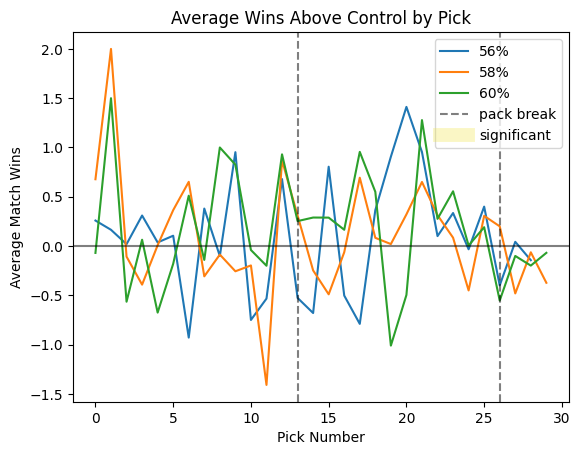

In [46]:
#plt.plot(results_df[['control_wins']])

plt.title('Average Wins Above Control by Pick')
plt.xlabel('Pick Number')
plt.ylabel('Average Match Wins')


plt.plot((dfT256['treatment_wins'] - dfT256['control_wins']), label='56%')
plt.plot((dfT258['treatment_wins'] - dfT258['control_wins']), label='58%')
plt.plot((dfT260['treatment_wins'] - dfT260['control_wins']), label='60%')

'''
for i, row in results_df.iterrows():
    if row['sig']:
        plt.axvspan(i - 0.5, i + 0.5, alpha=0.15, color='#f0e442')
'''

plt.axvline(x=13, color='black', linestyle='--', alpha=0.5, label='pack break')
plt.axhline(y=0, color='black', alpha=0.5)
plt.axvline(x=26, color='black', linestyle='--', alpha=0.5)
plt.plot([], [], color='#f0e442', linewidth=10, label='significant', alpha=0.3)
#plt.errorbar(results_df[['treatment_wins']], treatment_wins, yerr=treatment_ci)
plt.legend()

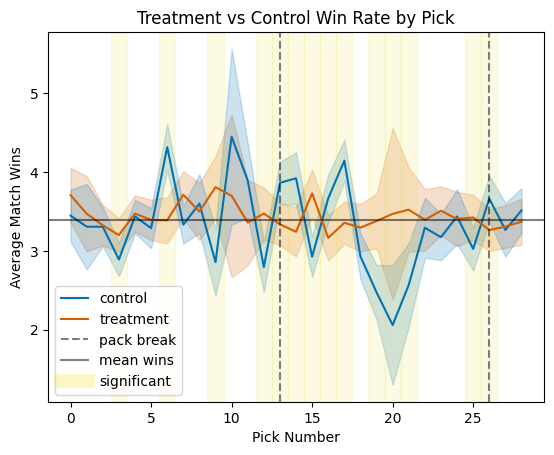

In [47]:
results_df = dfT256
mean_wins = pd.concat([results_df['treatment_wins'],results_df['control_wins']]).mean()

x = range(len(results_df))

plt.title('Treatment vs Control Win Rate by Pick')
plt.xlabel('Pick Number')
plt.ylabel('Average Match Wins')

plt.plot(x, results_df['control_wins'], label='control', color='#0072b2')
plt.plot(x, results_df['treatment_wins'], label='treatment', color='#d55e00')

plt.fill_between(x, 
    results_df['treatment_wins'] - results_df['treatment_ci'],
    results_df['treatment_wins'] + results_df['treatment_ci'],
    alpha=0.2, color='#d55e00')

plt.fill_between(x,
    results_df['control_wins'] - results_df['control_ci'],
    results_df['control_wins'] + results_df['control_ci'],
    alpha=0.2, color='#0072b2')

for i, row in results_df.iterrows():
    if row['sig']:
        plt.axvspan(i - 0.5, i + 0.5, alpha=0.15, color='#f0e442')

plt.axvline(x=13, color='black', linestyle='--', alpha=0.5, label='pack break')
plt.axvline(x=26, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=mean_wins, color='black', alpha=0.5, label = 'mean wins')
plt.plot([], [], color='#f0e442', linewidth=10, label='significant', alpha=0.3)


plt.legend()
plt.show()

ValueError: The number of FixedLocator locations (29), usually from a call to set_ticks, does not match the number of labels (42).

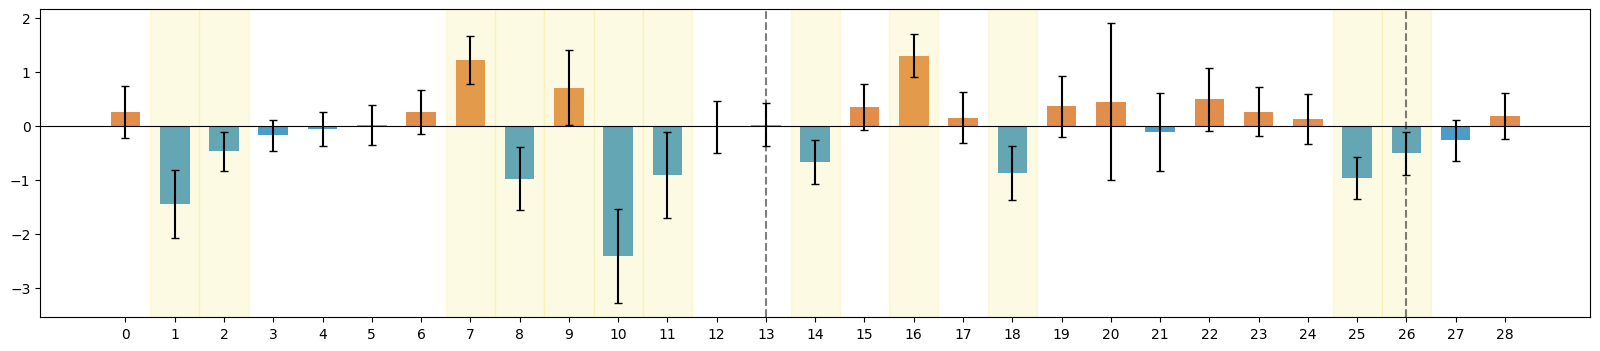

In [64]:
results_df = dfT262
x = range(len(results_df))

fig, ax = plt.subplots(figsize=(20, 4))

wins_above_control = results_df['treatment_wins'] - results_df['control_wins']
ci = np.sqrt(results_df['treatment_ci']**2 + results_df['control_ci']**2)

ax.bar(x, wins_above_control, width=0.6,
       alpha=0.7, yerr=ci, capsize=3,
       color=np.where(wins_above_control >= 0, '#d55e00', '#0072b2'))

for i, row in results_df.iterrows():
    if row['sig']:
        plt.axvspan(i - 0.5, i + 0.5, alpha=0.15, color='#f0e442')


ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xticks(x)
plt.axvline(x=13, color='black', linestyle='--', alpha=0.5, label='pack break')
plt.axvline(x=26, color='black', linestyle='--', alpha=0.5)
ax.set_xticklabels([f"p{int(r.pack)+1}p{int(r.pick)}" for _, r in results_df.iterrows()], rotation=90)
#ax.set_xticklabels(range(1,43))
ax.set_ylabel('Wins Above Control')
ax.set_title('Treatment Effect by Pick (62% Win Rate)')
plt.tight_layout()
plt.show()

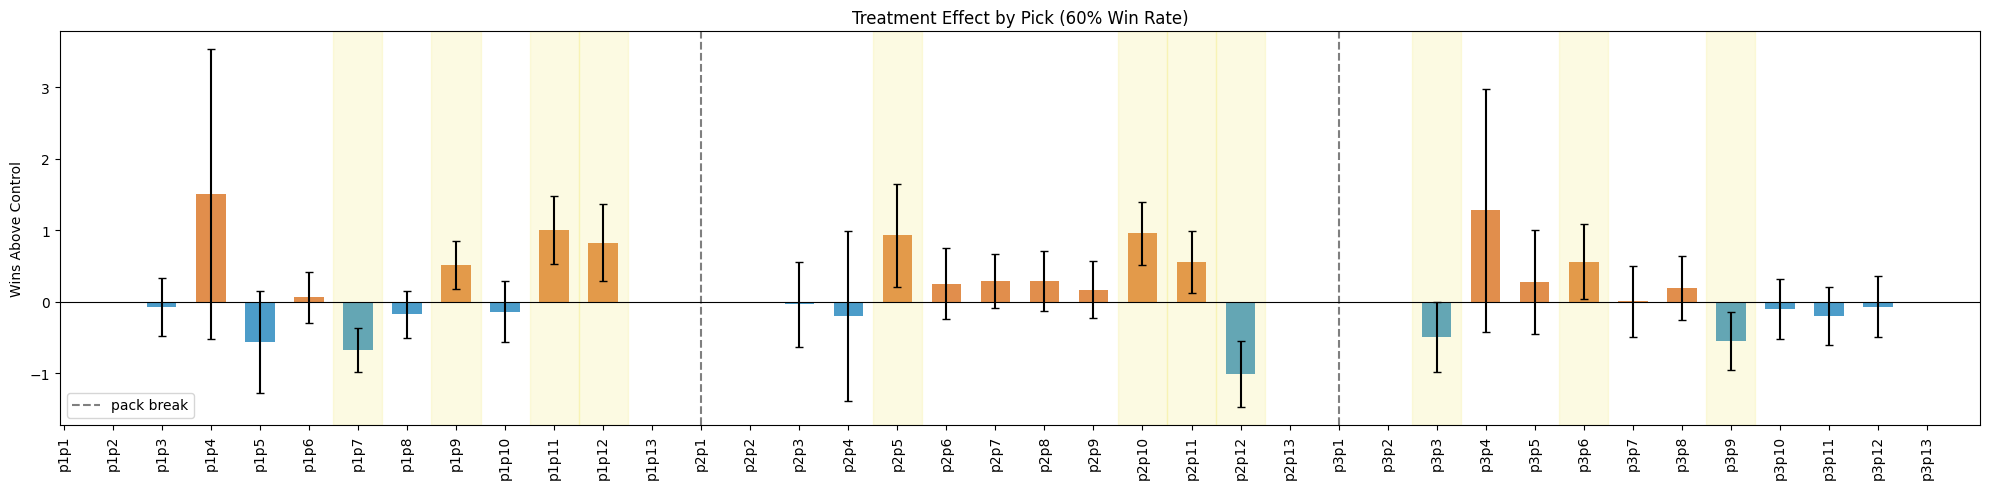

In [97]:
results_df = dfT260

all_labels = [f"p{pack}p{pick}" for pack in range(1, 4) for pick in range(1, 14)]
results_df['label'] = results_df.apply(lambda r: f"p{int(r.pack)+1}p{int(r.pick)}", axis=1)
results_df_reindexed = results_df.set_index('label').reindex(all_labels)

x = range(len(all_labels))

fig, ax = plt.subplots(figsize=(20, 5))

wins_above_control = results_df_reindexed['treatment_wins'] - results_df_reindexed['control_wins']
ci = np.sqrt(results_df_reindexed['treatment_ci']**2 + results_df_reindexed['control_ci']**2)

ax.bar(x, wins_above_control, width=0.6,
       alpha=0.7, yerr=ci, capsize=3,
       color=np.where(wins_above_control >= 0, '#d55e00', '#0072b2'))

for i, label in enumerate(all_labels):
    if label in results_df.set_index('label').index:
        row = results_df.set_index('label').loc[label]
        if row['sig']:
            plt.axvspan(i - 0.5, i + 0.5, alpha=0.15, color='#f0e442')

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xticks(x)
plt.axvline(x=13, color='black', linestyle='--', alpha=0.5, label='pack break')
plt.axvline(x=26, color='black', linestyle='--', alpha=0.5)
ax.set_xticklabels(all_labels, rotation=90)
ax.set_ylabel('Wins Above Control')
ax.set_title('Treatment Effect by Pick (60% Win Rate)')
plt.tight_layout()
plt.legend()
plt.show()